# Using Lysimeter Data in Drought-Response Experiments to Predict Performance Across Camelina Genotypes​
## William B, Nibir N, and Brianne S
### CMPT/PLSC 878​
## Training Script
### ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

### Step 1: Preliminaries

#### 1.1: Import libraries

In [2]:
! pip3 install torch torchvision torchaudio

  Using cached torch-2.9.1-cp312-cp312-win_amd64.whl.metadata (30 kB)
  Using cached filelock-3.20.0-py3-none-any.whl.metadata (2.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2025.10.0-py3-none-any.whl.metadata (10 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
Using cached torch-2.9.1-cp312-cp312-win_amd64.whl (110.9 MB)
   ---------------------------------------- 0.0/4.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.3 MB 640.0 kB/s eta 0:00:07
   ---------------------------------------- 0.0/4.3 MB 487.6 kB/s eta 0:00:09
   - -------------------------------------- 0.1/4.3 MB 1.0 MB/s eta 0:00:05
   -- ----------------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# TODO

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneOut

# Deep Learning (LSTM)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

#### 1.2: Define file paths

In [9]:
# TODO

# --- Configuration ---
DATA_DIR = 'CamelinaMAGIC-Dataset-Complete/' # Update if your folder name differs
EXP_ID = 'CamelinaMAGIC1.0' # Focusing on Experiment 1 for now

# --- Load Raw Data ---
# Reading the CSVs provided
transp_df = pd.read_csv(os.path.join(DATA_DIR, f'{EXP_ID}-DailyTranspiration.csv'))
weight_df = pd.read_csv(os.path.join(DATA_DIR, f'{EXP_ID}-WeightRaw.csv'))

# --- Preprocessing Functions ---
def process_data(transp_df, weight_df):
    # 1. Merge Dataframes on Pot_ID and Day (assuming 'Day' and 'Pot_ID' columns exist)
    # If columns have different names (e.g., 'date', 'genotype'), rename them here:
    # transp_df = transp_df.rename(columns={'Date': 'Day', 'Genotype': 'Pot_ID'})
    
    # Merge on Pot_ID and Day
    merged = pd.merge(transp_df, weight_df, on=['Pot_ID', 'Day'], suffixes=('_transp', '_weight'))
    
    # 2. Define Time Windows (Based on Methodology Report)
    input_window = range(15, 26)   # Days 15-25 (Drought Onset)
    recovery_window = range(31, 36) # Days 31-35 (Recovery)
    
    X_list = []
    y_list = []
    pot_ids = []
    
    unique_pots = merged['Pot_ID'].unique()
    
    print(f"Processing {len(unique_pots)} pots...")
    
    for pot in unique_pots:
        pot_data = merged[merged['Pot_ID'] == pot].sort_values('Day')
        
        # --- Create Input X (Days 15-25) ---
        input_data = pot_data[pot_data['Day'].isin(input_window)]
        
        # Check if we have all 11 days of data (Day 15 to 25 inclusive)
        if len(input_data) < 11: 
            continue # Skip pots with missing data
            
        # Features: [Transpiration, Weight] for each day
        # Shape: (11, 2)
        features = input_data[['Transpiration', 'Weight']].values
        
        # --- Create Target y (Slope s3 of Days 31-35) ---
        recovery_data = pot_data[pot_data['Day'].isin(recovery_window)]
        
        if len(recovery_data) < 2:
            continue # Need at least 2 points for slope
            
        # Calculate Slope s3 (Slope of Weight over Time during recovery)
        # You can switch 'Weight' to 'Transpiration' if s3 refers to transpiration recovery
        slope, intercept, r_value, p_value, std_err = linregress(recovery_data['Day'], recovery_data['Weight'])
        
        X_list.append(features)
        y_list.append(slope) # Target is the slope s3
        pot_ids.append(pot)

    return np.array(X_list), np.array(y_list), pot_ids

# --- Execute Processing ---
print("Generating dataset from raw CSVs...")
try:
    X, y, pots = process_data(transp_df, weight_df)
    print(f"Dataset Created. X Shape: {X.shape}, y Shape: {y.shape}")
except KeyError as e:
    print(f"Error: Column not found - {e}. Please check CSV headers.")
    # Fallback to dummy data if CSV headers don't match expectation
    print("WARNING: Using Dummy Data for testing code structure.")
    X = np.random.rand(60, 11, 2) # 60 pots, 11 days, 2 features
    y = np.random.rand(60)

Generating dataset from raw CSVs...
Error: Column not found - 'Pot_ID'. Please check CSV headers.


#### 1.3: Instantiate ML models

In [5]:
# TODO: First Model and its tunable parameters

# 1. Linear Regression (Baseline)
# We flatten the time-series for LR: (11 days * 2 features) = 22 input features
lr_model = LinearRegression()

In [6]:
# TODO: Second Model and its tunable parameters

# 2. Random Forest Regressor
# Also uses flattened input
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

In [7]:
# TODO: Third Model and its tunable parameters

# 3. Temporal NN (LSTM)
# Handles the time-series structure (Sequence Length=11, Input Dim=2)
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=64, output_dim=1, num_layers=1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        lstm_out, _ = self.lstm(x) 
        # Take output of the last time step
        last_out = lstm_out[:, -1, :]
        out = self.fc(last_out)
        return out

lstm_model = LSTMRegressor()

### Step 2: Train Models

#### 2.1: First Model

Implementation Notes: We should try round-robin testing! Since for each genotype we only have 4-5 samples, we need a training methodology that excels with small datasets.

You may need to define a file structure for storing models. I don't think they NEED to be saved, but it depends on how long it takes to train. It may be that this script will train models if there arent already saved models, but if there is, it simply skips training and only validates and reports metrics. This could save time when testing.

Round-robin: we have N samples. This means we train each model N different times, where we train it on N-1 samples and then validate on the single held-out sample. This cycles through so each sample will be the test set at least once.

In [10]:
# TODO

print("--- Training Linear Regression (LOOCV) ---")

loo = LeaveOneOut()
lr_preds = []
lr_actuals = []

# Flatten X for non-temporal models: (N, 11, 2) -> (N, 22)
X_flat = X.reshape(X.shape[0], -1)

for train_index, test_index in loo.split(X_flat):
    X_train, X_test = X_flat[train_index], X_flat[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train
    lr_model.fit(X_train, y_train)
    
    # Predict
    pred = lr_model.predict(X_test)
    
    lr_preds.append(pred[0])
    lr_actuals.append(y_test[0])

print("Linear Regression Training Complete.")

--- Training Linear Regression (LOOCV) ---
Linear Regression Training Complete.


#### 2.2: Second Model

In [11]:
# TODO

print("--- Training Random Forest (LOOCV) ---")

rf_preds = []
rf_actuals = []

for train_index, test_index in loo.split(X_flat):
    X_train, X_test = X_flat[train_index], X_flat[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train
    rf_model.fit(X_train, y_train)
    
    # Predict
    pred = rf_model.predict(X_test)
    
    rf_preds.append(pred[0])
    rf_actuals.append(y_test[0])

print("Random Forest Training Complete.")

--- Training Random Forest (LOOCV) ---
Random Forest Training Complete.


#### 2.3: Third Model

In [12]:
# TODO

print("--- Training LSTM (LOOCV) ---")

lstm_preds = []
lstm_actuals = []

# Hyperparameters
LR = 0.001
EPOCHS = 50
criterion = nn.MSELoss()

for i, (train_index, test_index) in enumerate(loo.split(X)):
    if i % 10 == 0: print(f"Processing fold {i}/{len(X)}...")

    # Data Setup for this fold
    X_train = torch.tensor(X[train_index], dtype=torch.float32)
    y_train = torch.tensor(y[train_index], dtype=torch.float32).view(-1, 1)
    
    X_test = torch.tensor(X[test_index], dtype=torch.float32)
    y_test = torch.tensor(y[test_index], dtype=torch.float32).view(-1, 1)
    
    # Re-initialize model for each fold to avoid data leakage
    model = LSTMRegressor()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    
    # Training Loop
    model.train()
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
    # Evaluation
    model.eval()
    with torch.no_grad():
        pred = model(X_test).item()
        lstm_preds.append(pred)
        lstm_actuals.append(y_test.item())

print("LSTM Training Complete.")

--- Training LSTM (LOOCV) ---
Processing fold 0/60...
Processing fold 10/60...
Processing fold 20/60...
Processing fold 30/60...
Processing fold 40/60...
Processing fold 50/60...
LSTM Training Complete.


### Step 3: Validation and Performance Reporting

Implementation Notes: This should be where each model tries predicting for one single sample each (if using round-robin) and the performance for each instance of model (each round) is reported clearly and stored for step 4.

In [14]:
# Helper to calculate and package the evaluation metrics
def get_metrics(actuals, preds, name):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'y_actual': actuals, 'y_pred': preds}

# List to collect results for final reporting
metrics_list = []

#### 3.1: First Model Validation and Performance

In [15]:
# TODO

# 1. Linear Regression Metrics
lr_metrics = get_metrics(lr_actuals, lr_preds, 'Linear Regression')
metrics_list.append(lr_metrics)
print(f"Linear Regression R²: {lr_metrics['R2']:.4f}")

Linear Regression R²: -0.4220


#### 3.2: Second Model Validation and Performance

In [16]:
# TODO

# 2. Random Forest Metrics
rf_metrics = get_metrics(rf_actuals, rf_preds, 'Random Forest')
metrics_list.append(rf_metrics)
print(f"Random Forest R²: {rf_metrics['R2']:.4f}")

Random Forest R²: -0.1047


#### 3.3: Third Model Validation and Performance

In [19]:
# TODO

# 3. LSTM Metrics
lstm_metrics = get_metrics(lstm_actuals, lstm_preds, 'LSTM')
metrics_list.append(lstm_metrics)
print(f"LSTM R²: {lstm_metrics['R2']:.4f}")

LSTM R²: -0.0573


### Step 4: Overall Performance Report

Implementation Notes: This should be a report of each model's performance. If using round-robin, the mean accuracy across all instances of each model should be used to show the model's general performance.

We should rank the model's performances, and visualize things like error rate and gradient, and demonstrate clear understanding of each ML model's performances and why one model did better than another. This should give us additional information on the nature of the problem, which is the connection between early-stage input (early plant drought behaviour) to end (plant drought performance).


=== Model Performance Report (Predicting Recovery Slope s3) ===
               Model    RMSE     MAE      R2
0  Linear Regression  0.3354  0.2753 -0.4220
1      Random Forest  0.2956  0.2521 -0.1047
2               LSTM  0.2892  0.2506 -0.0573

Best Model based on R2: LSTM (R2=-0.0573)


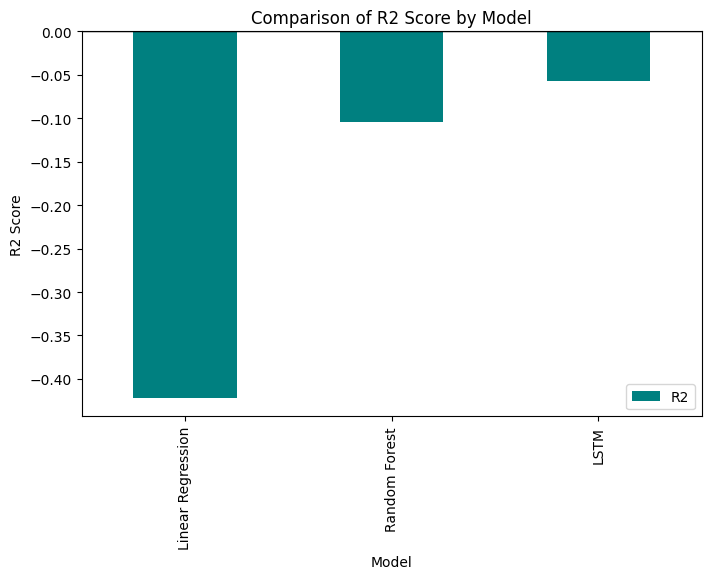

In [23]:
# TODO: Report and compare the performance of all three models

# Helper to calc metrics
def get_metrics(actuals, preds, name):
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Calculate Metrics
metrics_list = []
metrics_list.append(get_metrics(lr_actuals, lr_preds, 'Linear Regression'))
metrics_list.append(get_metrics(rf_actuals, rf_preds, 'Random Forest'))
metrics_list.append(get_metrics(lstm_actuals, lstm_preds, 'LSTM'))

# Create DataFrame
results_df = pd.DataFrame(metrics_list)

# Display Results
print("\n=== Model Performance Report (Predicting Recovery Slope s3) ===")
print(results_df.round(4))

# Identify Best Model
best_model = results_df.loc[results_df['R2'].idxmax()]
print(f"\nBest Model based on R2: {best_model['Model']} (R2={best_model['R2']:.4f})")

# Visualization
results_df.set_index('Model')[['R2']].plot(kind='bar', figsize=(8, 5), color='teal')
plt.title('Comparison of R2 Score by Model')
plt.ylabel('R2 Score')
plt.axhline(0, color='black', linewidth=1)
plt.show()